In [33]:
%matplotlib inline
import brian2 as b2
import matplotlib.pyplot as plt
import numpy as np
#from neurodynex3.leaky_integrate_and_fire import LIF
#rom neurodynex3.tools import input_factory, plot_tools


# parameters in SI units: volts, seconds, ohms, amps
V_rest  = -0.070    # -70 mV
V_reset = -0.065    # -65 mV
V_peak = -0.030 #-30mV is high enough to see the spike form
V_th    = -0.050    # -50 mV  firing threshold
theta_rh = -0.050  # same as V_th
Delta_T = 2e-3  # testing different values from textbook
R       = 10e6      # 10 MΩ
tau     = 8e-3      # 8 ms  membrane time constant
t_refr  = 2e-3      # 2 ms  absolute refractory period
dt = 1e-4;


def simulate_lif(I, dt, V_rest,V_reset,V_th, R, tau, t_refr):
    #simulate LIF model through differential equation itself
    n = len(I)
    V=np.zeros(n)
    V[0] = V_rest
    spike_times = []
    refr_steps = int(round(t_refr / dt))   # how many steps to stay clamped
    refr_counter = 0                       # >0 means we're inside refractory

    for k in range(n-1):
        if refr_counter>0:
            V[k+1] = V_reset
            refr_counter -= 1
            continue 
        #differential equation
        dV = (dt / tau) * (-(V[k] - V_rest) + R * I[k])
        V[k+1] = V[k] + dV

        # record spike timings 

        if V[k] < V_th and V[k+1] >= V_th:
            spike_times.append((k+1) * dt)
            V[k+1] = V_reset #reset
            refr_counter = refr_steps
    t = np.arange(n)* dt 
    return t, V, spike_times
def simulate_eif(I, dt, V_rest,V_reset, v_peak, R, tau, t_refr, theta_rh, Delta_T):
    #simulate exp-LIF model through differential equation itself
    n = len(I)
    V=np.zeros(n)
    V[0] = V_rest
    spike_times = []
    refr_steps = int(round(t_refr / dt))   # how many steps to stay clamped
    refr_counter = 0                       # >0 means we're inside refractory

    for k in range(n-1):
        if refr_counter>0:
            V[k+1] = V_reset
            refr_counter -= 1
            continue 
        #differential equation
        arg = np.clip((V[k] - theta_rh) / Delta_T, -50, 20)
        dV = (dt / tau) * (-(V[k] - V_rest) + Delta_T * np.exp(arg) + R * I[k]) #adding in exponential term
        V[k+1] = V[k] + dV

        # record spike timings 
        # no set threshold, so once we meet the threshold a spike occurs (after threshold it increases exponentially to infinity
        if V[k+1] >= V_peak:
            spike_times.append((k+1) * dt)
            V[k+1] = V_reset #reset
            refr_counter = refr_steps
    t = np.arange(n)* dt 
    return t, V, spike_times

    
def make_pulse_train(n, dt, amplitude, pulse_width, period, t_start):
    #start with zero, then between two steps we switch current on for w steps, for a period, then off
    I = np.zeros(n)
    w     = int(round(pulse_width / dt))   # pulse width in steps
    p     = int(round(period / dt))        # period in steps
    start = int(round(t_start / dt))
    for k0 in range(start, n, p):          # k0 = start of each pulse
        I[k0:k0 + w] = amplitude
    return I

def make_repeated_pattern(pattern, n_repeats, gap_steps=0):
    """
    pick 5 random current values, hold each one for 2ms each (how does that get 20?) creating pattern to be one short random staircase waveform
    """
    gap = np.zeros(gap_steps)
    blocks = []
    for _ in range(n_repeats):
        blocks.append(pattern)
        blocks.append(gap)
    return np.concatenate(blocks)

number of spikes: 0


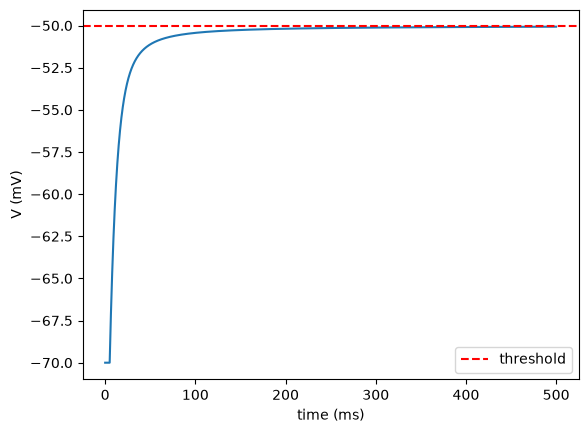

1.8e-09 8.910000000000001e-06


In [16]:
# test 1 - subthreshold to see if the neuron does not fire if it does not reach rheobase threshold
T = 0.5; dt = 1e-4; n = int(round(T/dt))
I_sub = np.zeros(n); I_sub[int(0.005/dt):] = 1.8e-9       # the exponential term allows it to operate below 2nA, so i test with 1..5
t,V,spikes = simulate_eif(I_sub, dt, V_rest, V_reset, V_peak, R, tau, t_refr, theta_rh, Delta_T)
print("number of spikes:", len(spikes))   # expect 0
plt.plot(t*1000, V*1000)
plt.axhline(-50, ls='--', color='r', label='threshold')
plt.xlabel("time (ms)"); plt.ylabel("V (mV)"); plt.legend()
plt.show()



'''
shows model is working as subthreshold is now lower, 1.8nA is the minimum current to reach the threshold, lowered due to the exponential term
''' 

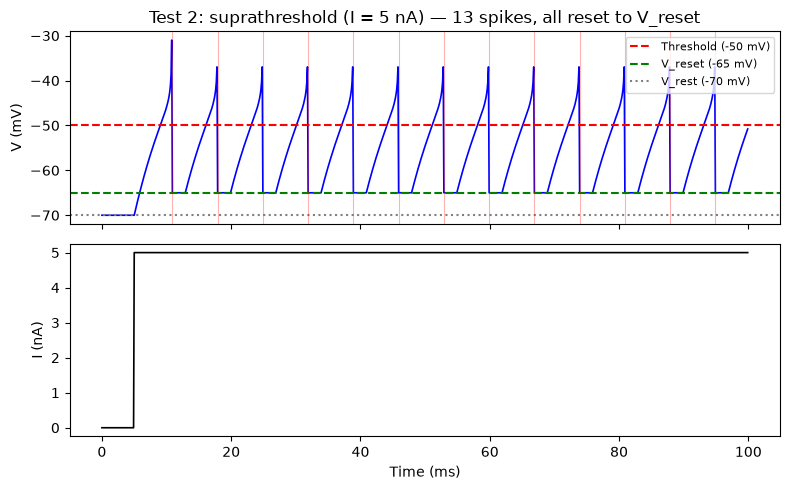

Post-spike voltage: -65.0 mV — expected -65 mV


In [18]:
# testing whether it resets back to reset threshold - applying 5nA current to test after spike it resets, also to see the shape

T = 0.1; dt = 1e-4; n = int(round(T/dt))
I_sup = np.zeros(n); I_sup[int(0.005/dt):] = 5e-9
t_arr, V_arr, spikes = simulate_eif(I_sup, dt, V_rest, V_reset, V_peak, R, tau, t_refr, theta_rh, Delta_T)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

# Top panel: voltage trace
axes[0].plot(t_arr*1000, V_arr*1000, 'b', lw=1.2)
axes[0].axhline(V_th*1000,    ls='--', color='r',  label=f'Threshold ({V_th*1000:.0f} mV)')
axes[0].axhline(V_reset*1000, ls='--', color='g',  label=f'V_reset ({V_reset*1000:.0f} mV)')
axes[0].axhline(V_rest*1000,  ls=':',  color='gray', label=f'V_rest ({V_rest*1000:.0f} mV)')
for t_sp in spikes:
    axes[0].axvline(t_sp*1000, color='r', alpha=0.3, lw=0.8)
axes[0].set_ylabel("V (mV)")
axes[0].set_title(f"Test 2: suprathreshold (I = 5 nA) — {len(spikes)} spikes, all reset to V_reset")
axes[0].legend(fontsize=8)

# Bottom panel: input current
axes[1].plot(t_arr*1000, I_sup*1e9, 'k', lw=1.2)
axes[1].set_ylabel("I (nA)")
axes[1].set_xlabel("Time (ms)")

plt.tight_layout()
plt.show()

print(f"Post-spike voltage: {V_arr[int(spikes[0]/dt) + 1]*1000:.1f} mV — expected {V_reset*1000:.0f} mV")

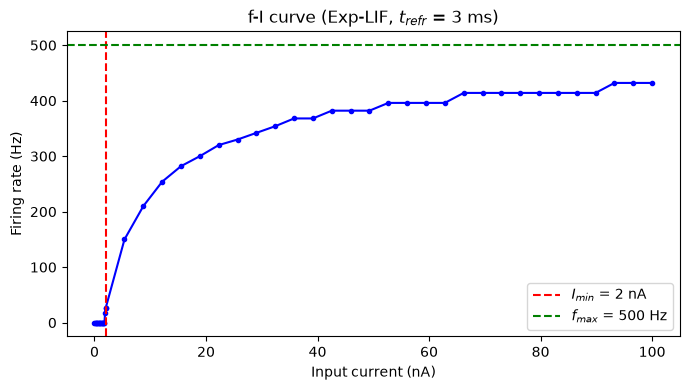

Max observed rate: 432.0 Hz  (theory cap: 500 Hz)


In [28]:
# f-I curve

T_sim = 0.5          # 500 ms per run
dt    = 1e-4
n     = int(round(T_sim / dt))



I_values = np.concatenate([
    np.linspace(0, 2e-9, 20),     # fine resolution near rheobase
    np.linspace(2e-9, 100e-9, 30) # coarser above
])
firing_rates = []
for I_amp in I_values:
    I_arr = np.zeros(n)
    I_arr[int(0.005/dt):] = I_amp # build a step current of current amplitude
    _, _, spikes = simulate_eif(I_arr, dt, V_rest, V_reset, V_peak, R, tau, t_refr, theta_rh, Delta_T) #simulate neuron output with this current
    firing_rates.append(len(spikes) / T_sim)   # rate is spikes / time

firing_rates = np.array(firing_rates)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(I_values * 1e9, firing_rates, 'b.-')
plt.axvline(2.0, ls='--', color='r', label='$I_{min}$ = 2 nA')
plt.axhline(1/t_refr, ls='--', color='g', label=f'$f_{{max}}$ = {1/t_refr:.0f} Hz')
plt.xlabel("Input current (nA)")
plt.ylabel("Firing rate (Hz)")
plt.title("f-I curve (Exp-LIF, $t_{refr}$ = 3 ms)")
plt.legend(); plt.tight_layout()
plt.show()

# Sanity check
print(f"Max observed rate: {firing_rates.max():.1f} Hz  (theory cap: {1/t_refr:.0f} Hz)")


In [34]:
T = 0.1; dt = 1e-4; I_amp = 5e-9
n = int(round(T / dt))
I = np.zeros(n); I[int(0.005/dt):] = I_amp

# first get the LIF spike count as the target
_, _, spikes_lif = simulate_lif(I, dt, V_rest, V_reset, V_th, R, tau, t_refr)
print(f"LIF target: {len(spikes_lif)} spikes")

# now sweep Delta_T downward
for DT in [2e-3, 1e-3, 0.5e-3, 0.1e-3]:
    _, _, spikes = simulate_eif(I, dt, V_rest, V_reset, V_peak, R, tau, t_refr, theta_rh, DT)
    print(f"Delta_T = {DT*1e3:.2f} mV → {len(spikes)} spikes")

LIF target: 18 spikes
Delta_T = 2.00 mV → 13 spikes
Delta_T = 1.00 mV → 15 spikes
Delta_T = 0.50 mV → 16 spikes
Delta_T = 0.10 mV → 17 spikes
